In [1]:
# iris(붓꽃 데이터) 기반 통계분석, 비지도학습

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from scipy import stats

In [5]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [6]:
from sklearn.datasets import load_iris

In [7]:
iris = load_iris()
iris # 사전 구조, 정확하게는 Buch : 사전과 유사한 scikit-learn의 객체

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [8]:
# DataFrame 형태로 만든다.
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
df['y'] = iris.target # 정답
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [10]:
df['species'] = df['y'].map( {0:'setosa', 1:'versicolor', 2:'virginica'} )
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [11]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'y', 'species'],
      dtype='str')

In [12]:
df.columns = [ 'sepal_length', 'sepal_width', 'petal_length', 'petal_width',
              'y', 'species']
df

,sepal_length,sepal_width,petal_length,petal_width,y,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   y             150 non-null    int32  
 5   species       150 non-null    str    
dtypes: float64(4), int32(1), str(1)
memory usage: 6.6 KB


In [14]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width,y
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [15]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [16]:
numeric_cols = [ 'sepal_length', 'sepal_width', 'petal_length', 'petal_width' ]

In [17]:
# 품종에 따른 숫자 컬럼들의 평균
df.groupby('species')[numeric_cols].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [18]:
# 상관계수
corr_matrix = df[numeric_cols].corr().round(3)
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


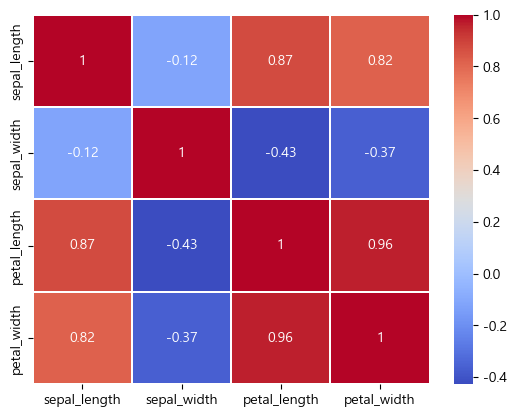

In [19]:
sns.heatmap(corr_matrix, annot=True, linewidths=0.1, cmap=plt.cm.coolwarm);

In [20]:
# 피어슨 상관계수
r, p_value = stats.pearsonr( df['petal_length'], df['petal_width'] )
print(f"상관계수(r) = {r:.4f}")
print(f"p-value = {p_value:.2e}")
print(f"해석: {'차이가 있다(0.05 미만==>대립가설 채택)' if p_value < 0.05 else '귀무가설'}")

상관계수(r) = 0.9629
p-value = 4.68e-86
해석: 차이가 있다(0.05 미만==>대립가설 채택)


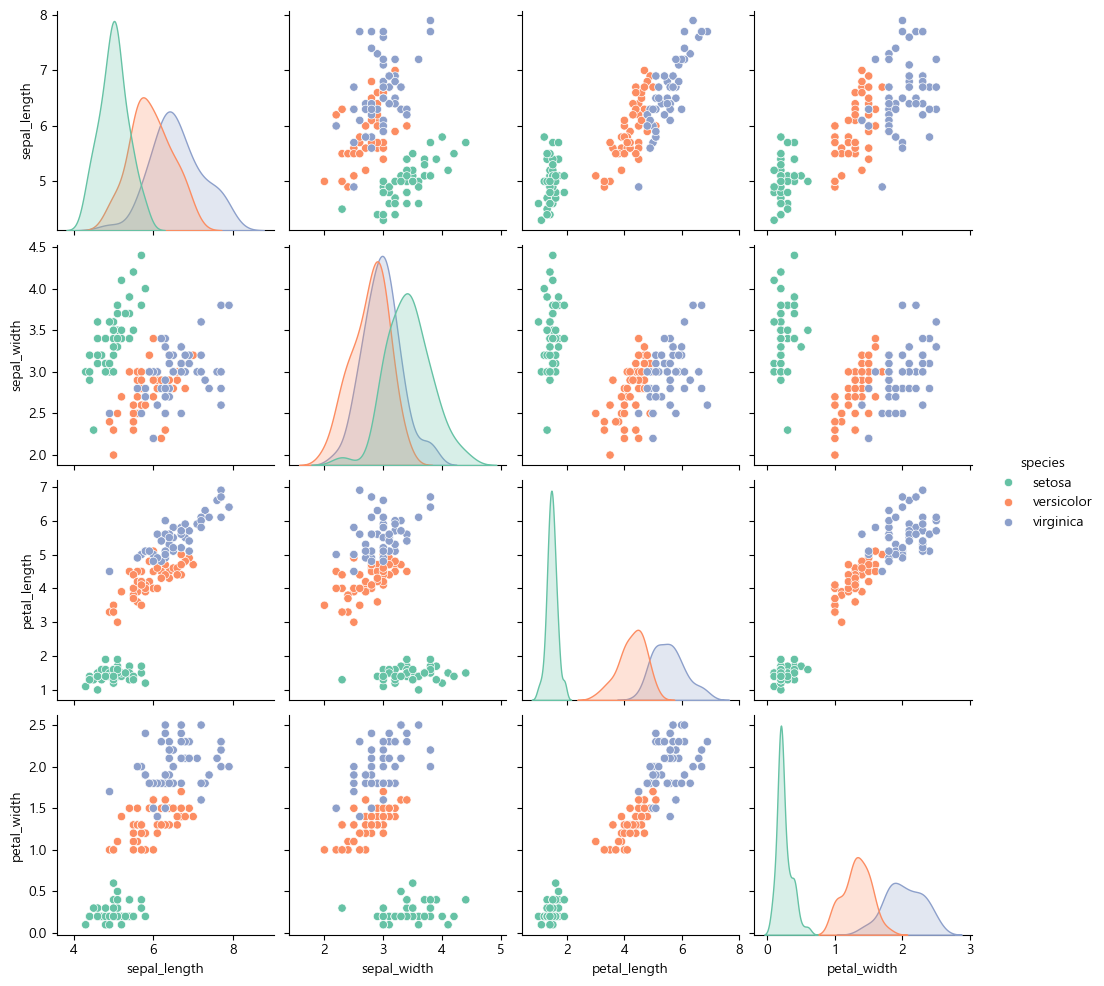

In [21]:
sns.pairplot(df, vars=numeric_cols, hue='species', palette='Set2');

In [22]:
setosa = df[ df['species'] == 'setosa' ]
versicolor = df[ df['species'] == 'versicolor' ]

In [23]:
setosa.shape, versicolor.shape

((50, 6), (50, 6))

In [24]:
# 독립표본 t-검정(independent t-test)
for col in numeric_cols:
    print( col, stats.ttest_ind(setosa[col], versicolor[col]) )
# 모든 컬럼에서 두 집단의 평균 차이가 매우 뚜렷함.
# pvalue 값이 0.05 미만이기 때문에 두 그룹은 통계적으로 유의미한 차이가 있다. 대립가설 채택
# statistic(t-통계량) : 두 그룹의 평균 차이가 표준 오차에 비해 얼마나 큰가?
# 양수(+) : 첫번째 그룹의 평균이 큼
# 음수(-) : 두번째 그룹의 평균이 큼
# 참고 : df(Degress of Freedom, 자유도), 전체 데이터 갯수 - 2, 100-2=98 => 0.98

sepal_length TtestResult(statistic=-10.52098626754911, pvalue=8.985235037487147e-18, df=98.0)
sepal_width TtestResult(statistic=9.454975848128596, pvalue=1.845259945476927e-15, df=98.0)
petal_length TtestResult(statistic=-39.492719391538095, pvalue=5.404910513441767e-62, df=98.0)
petal_width TtestResult(statistic=-34.08034154357719, pvalue=3.831095388248143e-56, df=98.0)


In [25]:
two_species = df[ (df['species'] == 'setosa') | (df['species'] == 'versicolor') ]
two_species

,sepal_length,sepal_width,petal_length,petal_width,y,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1,versicolor
96,5.7,2.9,4.2,1.3,1,versicolor
97,6.2,2.9,4.3,1.3,1,versicolor
98,5.1,2.5,3.0,1.1,1,versicolor


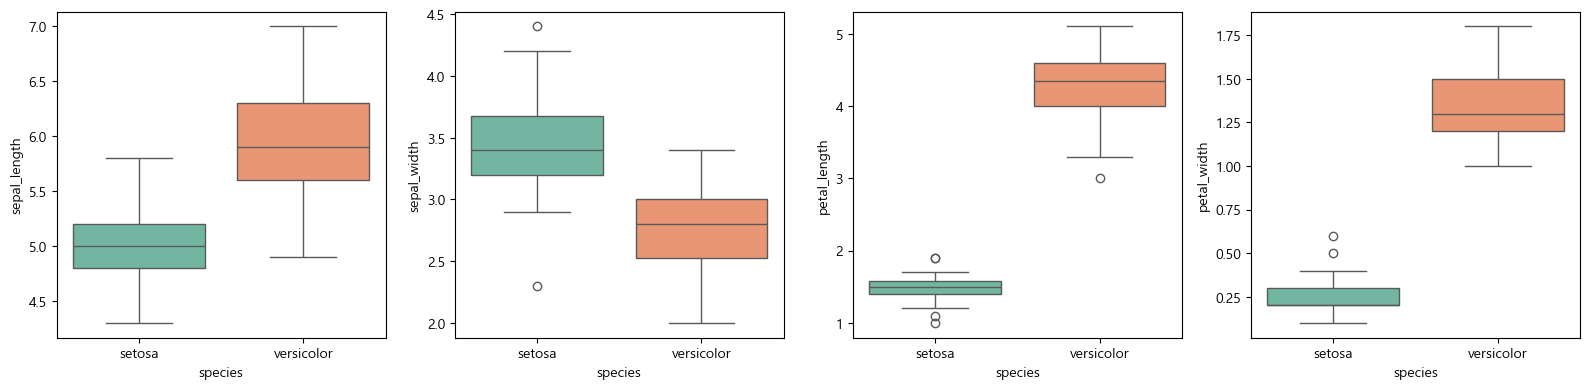

In [26]:
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_cols, 1): # 1부터 시작
    # print(i, col)
    plt.subplot(1, 4, i) # 141, 142, 143, 144
    sns.boxplot(data=two_species, x='species', y=col, palette='Set2')
plt.tight_layout()
plt.show()

In [27]:
setosa = df[ df['species'] == 'setosa' ]
versicolor = df[ df['species'] == 'versicolor' ]
virginica = df[ df['species'] == 'virginica' ]

In [28]:
print(df['species'].unique())
print(len(setosa), len(versicolor), len(virginica))

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
50 50 50


In [29]:
# ANOVA
for col in numeric_cols:
    print(col, stats.f_oneway(setosa[col], versicolor[col], virginica[col]))

sepal_length F_onewayResult(statistic=119.26450218450468, pvalue=1.6696691907693826e-31)
sepal_width F_onewayResult(statistic=49.160040089612075, pvalue=4.492017133309084e-17)
petal_length F_onewayResult(statistic=1180.161182252976, pvalue=2.856776610962404e-91)
petal_width F_onewayResult(statistic=960.0071468018067, pvalue=4.169445839443833e-85)


In [30]:
try:
    import statsmodels
except:
    %pip install statsmodels

In [31]:
# 사후검정(Tukey HSD)
# HSD (Honestly Significant Diffrence) : 진짜 유의미한 차이
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("=== 사후검정(Tukey HSD) ====")
for col in numeric_cols:
    print(f"--- {col} ---")
    tukey = pairwise_tukeyhsd(df[col], df['species'], alpha=0.05)
    print(tukey)
    print()

=== 사후검정(Tukey HSD) ====
--- sepal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------

--- sepal_width ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
    setosa versicolor   -0.658    0.0 -0.8189 -0.4971   True
    setosa  virginica   -0.454    0.0 -0.6149 -0.2931   True
versicolor  virginica    0.204 0.0088  0.0431  0.3649   True
------------------------------------------------------------

--- petal_length ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2 

In [32]:
# PCA(주성분 분석)

In [33]:
try:
    import mglearn
except:
    %pip install mglearn

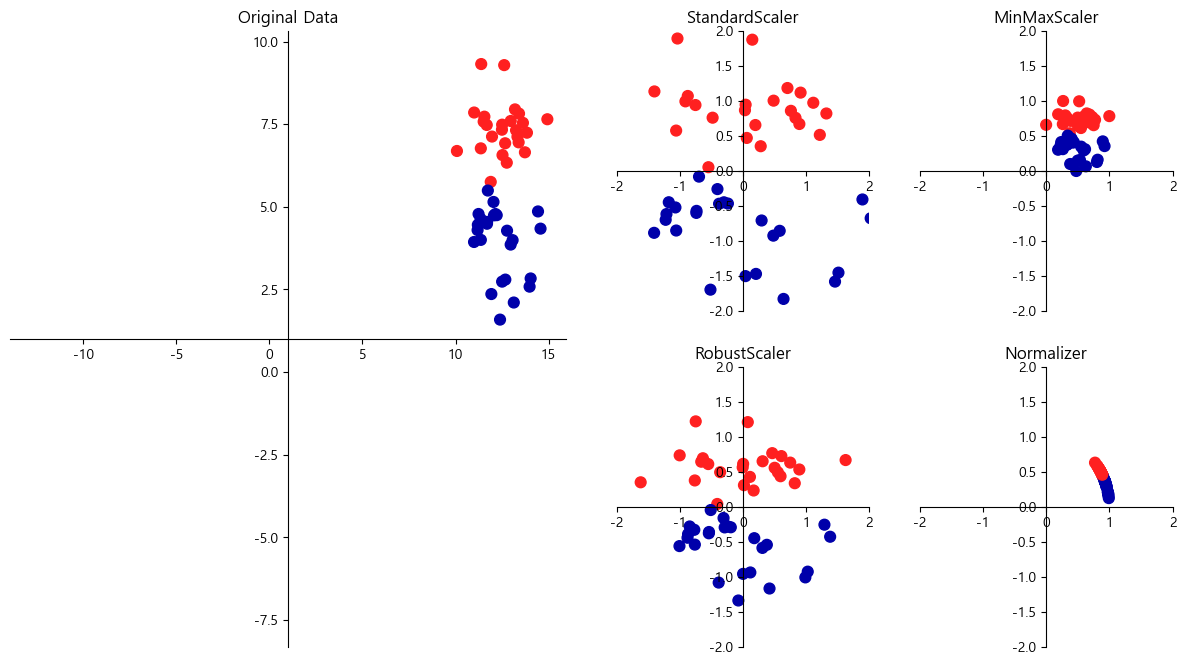

In [34]:
# 스케일링 그래프
mglearn.plots.plot_scaling()

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
X_scaled = scaler.fit_transform(df[numeric_cols])
X_scaled[0]

array([-0.90068117,  1.01900435, -1.34022653, -1.3154443 ])

In [38]:
print( df[numeric_cols].mean().values.round(2) )
print( X_scaled.mean().round(2) ) # 평균 : 0
print( X_scaled.std().round(2) ) # 표준편차 : 1

[5.84 3.06 3.76 1.2 ]
-0.0
1.0


In [39]:
from sklearn.decomposition import PCA

In [40]:
pca_full = PCA()

In [41]:
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [42]:
evrs = pca_full.explained_variance_ratio_
evrs

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

In [43]:
cumsum = np.cumsum( evrs )

In [44]:
print( evrs )
print( cumsum ) # 누적 설명력이 95%인 성분들을 선택한다 ==> PC1, PC2

[0.72962445 0.22850762 0.03668922 0.00517871]
[0.72962445 0.95813207 0.99482129 1.        ]


In [45]:
print("==== PCA 분산 설명력 ====")
print("주성분\t설명력\t누적 설명력")
# [0.72962445 0.22850762 0.03668922 0.00517871]
# [0.72962445 0.95813207 0.99482129 1.        ]
for i, (var, cum) in enumerate( zip( evrs, cumsum ) ):
    print( f"PC{i+1}\t{var:.4f}\t{cum:.4f}" )

==== PCA 분산 설명력 ====
주성분	설명력	누적 설명력
PC1	0.7296	0.7296
PC2	0.2285	0.9581
PC3	0.0367	0.9948
PC4	0.0052	1.0000


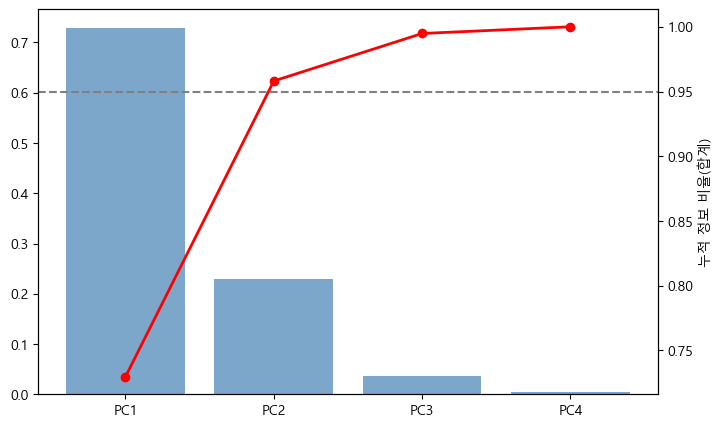

In [46]:
# pcs = [ f"PC{i+1}" for i in range( len(evrs) ) ] # len(evrs) ==> 4
# pcs = [ f"PC{i+1}" for i in range( 4 ) ] # range( 4 ) ==> [0,1,2,3]
# pcs = [ f"PC{i+1}" for i in [0,1,2,3] ] # ==> [ 'PC1', 'PC2', 'PC3', 'PC4' ]
# 위의 소스는 성분의 갯수가 많을 경우(예:50개) 일일이 타이핑하지 않고 PC1~PC50을 만드는 코드
pcs = [ 'PC1', 'PC2', 'PC3', 'PC4' ] # 현재 소스에서는 직접 타이핑해도 됨.
plt.figure(figsize=(8,5))
plt.bar(pcs, evrs, color='steelblue', alpha=0.7)
ax2 = plt.twinx() # X축 공유, 우측 Y축 사용
ax2.plot(pcs, cumsum, 'ro-', linewidth=2)
ax2.set_ylabel('누적 정보 비율(합계)') # 오른쪽 Y축의 이름 지정
ax2.axhline(y=0.95, color='gray', linestyle='--', label='95% 목표선')
plt.show() # 꺽이는 위치를 선택 ==> PC1과 PC2를 선택

In [47]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca[0]

array([-2.26470281,  0.4800266 ])

In [48]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = df['species']

evrs = pca.explained_variance_ratio_ # array([0.72962445, 0.22850762])
evr0 = evrs[0] # 0.72962445
evr1 = evrs[1] # 0.22850762

print(f"PC1의 설명력: {evr0:.4f} ({evr0*100:.1f}%)")
print(f"PC2의 설명력: {evr1:.4f} ({evr1*100:.1f}%)")
print(f"누적 설명력: {sum(evrs)*100:.1f}%")

PC1의 설명력: 0.7296 (73.0%)
PC2의 설명력: 0.2285 (22.9%)
누적 설명력: 95.8%


In [49]:
# end

In [50]:
L1 = [1,2,3,4,5]
L2 = [ ] # 빈 리스트 ==> [1, 4, 9, 16, 25]
for i in L1:
    L2.append( i ** 2 )
print(L2) # [1, 4, 9, 16, 25]

[1, 4, 9, 16, 25]


In [51]:
L3 = [ i ** 2 for i in L1 ] # # 리스트 표현식
# [  ] 를 제일 먼저 쓰고 그 안에 i**2 쓰고 for i in L1 를 쓰는 패턴(코딩 약속)
print(L3) # [1, 4, 9, 16, 25]

[1, 4, 9, 16, 25]
